In [12]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional, Annotated, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [4]:
class ModerationState(BaseModel):
    post_content: str
    user_reputation: str
    formatted_post: str
    content_flag: str
    result: str

In [5]:
def format_post(state: ModerationState):
    formatted = f"User ({state.user_reputation}) says: {state.post_content}"
    return{
        "formatted_post": formatted
    }

In [6]:
def analyze_content(state: ModerationState):
    content = state.post_content.lower()

    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state.user_reputation == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'

    return{
        'content_flag': flag
    }


In [7]:
def approve_post():
    resullt = 'Post published successfully to the timeline.'
    return{
        'result': resullt
    }


In [8]:
def flag_for_review():
    resullt = 'Post sent for evaluation'
    return{
        'result': resullt
    }


In [9]:
def reject_post():
    resullt = 'Post deleted due to violation.'
    return{
        'result': resullt
    }


In [13]:
def check_condition(state: ModerationState) -> Literal["approve_post", "flag_for_review", "reject_post"]:
    if state.content_flag == 'approved':
        return "approve_post"
    elif state.content_flag == 'review':
        return "flag_for_review"
    else:
        return "reject_post"

In [14]:
graph = StateGraph(ModerationState)

# nodes
graph.add_node('format_post', format_post)
graph.add_node('analyze_content', analyze_content)
graph.add_node('approve_post', approve_post)
graph.add_node('flag_for_review', flag_for_review)
graph.add_node('reject_post', reject_post)


# edges
graph.add_edge(START, 'format_post')
graph.add_edge('format_post', 'analyze_content')

graph.add_conditional_edges('analyze_content', check_condition)

workflow = graph.compile()

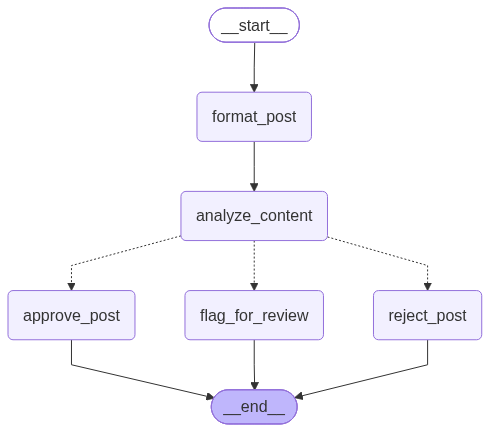

In [15]:
workflow